In [2]:
import subprocess
import sys

for pkg in ["causal-conv1d>=1.4.0", "mamba-ssm>=2.2.2"]:
    cmd = [sys.executable, "-m", "pip", "install", "--only-binary=:all:", "-v", pkg]
    print("+", " ".join(cmd), flush=True)
    subprocess.check_call(cmd)


+ /usr/bin/python3 -m pip install --only-binary=:all: -v causal-conv1d>=1.4.0


CalledProcessError: Command '['/usr/bin/python3', '-m', 'pip', 'install', '--only-binary=:all:', '-v', 'causal-conv1d>=1.4.0']' returned non-zero exit status 1.

In [1]:
# Mount Drive and locate cache/output roots.
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive")

cache_candidates = [
    DRIVE_ROOT / "utah_ssl" / "data" / "cache_v1",
    DRIVE_ROOT / "utah_ssl" / "data" / "v1_cache",
    DRIVE_ROOT / "cache_v1",
    DRIVE_ROOT / "v1_cache",
]

CACHE_ROOT = next((p for p in cache_candidates if p.exists()), cache_candidates[0])
OUTPUT_ROOT = DRIVE_ROOT / "utah_ssl" / "outputs" / "ssl_autoresearch"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("DRIVE_ROOT :", DRIVE_ROOT)
print("CACHE_ROOT :", CACHE_ROOT, "| exists:", CACHE_ROOT.exists())
print("OUTPUT_ROOT:", OUTPUT_ROOT, "| exists:", OUTPUT_ROOT.exists())

if CACHE_ROOT.exists():
    datasets = sorted(p.name for p in CACHE_ROOT.iterdir() if p.is_dir())
    print("datasets:", datasets)
else:
    print("cache candidates checked:")
    for p in cache_candidates:
        print(" -", p)



Mounted at /content/drive
DRIVE_ROOT : /content/drive/MyDrive
CACHE_ROOT : /content/drive/MyDrive/utah_ssl/data/cache_v1 | exists: True
OUTPUT_ROOT: /content/drive/MyDrive/utah_ssl/outputs/ssl_autoresearch | exists: True
datasets: ['000950', 'brain2text24', 'motor_data', 'plug_n_play', 'unsupervised_cursor_recalibration_offline', 'unsupervised_cursor_recalibration_online', 'willett_handwriting']


In [2]:
# Install Mamba fast-path deps with visible logs, then verify acceleration.
import subprocess
import sys

import torch

print("python        :", sys.version.split()[0])
print("torch         :", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("cuda version  :", torch.version.cuda)
if torch.cuda.is_available():
    print("gpu           :", torch.cuda.get_device_name(0))

def run(cmd):
    print("\n+", " ".join(cmd), flush=True)
    subprocess.check_call(cmd)

for pkg in ["causal-conv1d>=1.4.0", "mamba-ssm>=2.2.2"]:
    run([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-vv",
        "--no-build-isolation",
        pkg,
    ])

from transformers.utils.import_utils import is_causal_conv1d_available, is_mamba_ssm_available
import transformers.models.mamba.modeling_mamba as mm

causal_conv1d_update, causal_conv1d_fn = mm._lazy_load_causal_conv1d()
fast_path_ready = all([
    is_mamba_ssm_available(),
    is_causal_conv1d_available(),
    mm.selective_state_update is not None,
    mm.selective_scan_fn is not None,
    mm.mamba_inner_fn is not None,
    causal_conv1d_update is not None,
    causal_conv1d_fn is not None,
])

print("\nmamba_ssm available     :", is_mamba_ssm_available())
print("causal_conv1d available :", is_causal_conv1d_available())
print("selective_state_update  :", mm.selective_state_update is not None)
print("selective_scan_fn       :", mm.selective_scan_fn is not None)
print("mamba_inner_fn          :", mm.mamba_inner_fn is not None)
print("causal_conv1d_update    :", causal_conv1d_update is not None)
print("causal_conv1d_fn        :", causal_conv1d_fn is not None)
print("fast path ready         :", fast_path_ready)

if not fast_path_ready:
    raise RuntimeError(
        "Mamba fast-path kernels are still unavailable. "
        "If install failed or Colab asks for restart, restart the runtime and rerun this cell."
    )


python        : 3.12.13
torch         : 2.10.0+cu128
cuda available: True
cuda version  : 12.8
gpu           : NVIDIA L4

+ /usr/bin/python3 -m pip install -vv --no-build-isolation causal-conv1d>=1.4.0


KeyboardInterrupt: 

In [3]:
import subprocess
import sys

for pkg in ["causal-conv1d>=1.4.0", "mamba-ssm>=2.2.2"]:
    cmd = [sys.executable, "-m", "pip", "install", "--only-binary=:all:", "-v", pkg]
    print("+", " ".join(cmd), flush=True)
    try:
        subprocess.check_call(cmd)
    except subprocess.CalledProcessError as e:
        print(f"binary wheel install failed for {pkg}")


+ /usr/bin/python3 -m pip install --only-binary=:all: -v causal-conv1d>=1.4.0
binary wheel install failed for causal-conv1d>=1.4.0
+ /usr/bin/python3 -m pip install --only-binary=:all: -v mamba-ssm>=2.2.2
binary wheel install failed for mamba-ssm>=2.2.2


In [ ]:
# Clone the repo and set runtime paths.
# from pathlib import Path
# from google.colab import userdata
# import subprocess
#
# REPO_URL = "https://github.com/ethan-read/utah-ssl.git"
# REPO_DIR = Path("/content/utah-ssl")
#
# github_user = userdata.get("GITHUB_USER").strip()
# github_pat = userdata.get("GITHUB_PAT").strip()
#
# askpass = Path("/tmp/git_askpass.sh")
# askpass.write_text(
#     "#!/bin/sh\n"
#     'case "$1" in\n'
#     '  *Username*) echo "$GITHUB_USER" ;;\n'
#     '  *Password*) echo "$GITHUB_PAT" ;;\n'
#     "esac\n"
# )
# askpass.chmod(0o700)
#
# env = os.environ.copy()
# env["GIT_ASKPASS"] = str(askpass)
# env["GITHUB_USER"] = github_user
# env["GITHUB_PAT"] = github_pat
# env["GIT_TERMINAL_PROMPT"] = "0"
#
# if REPO_DIR.exists():
#     print("Using existing repo:", REPO_DIR)
# else:
#     subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True, env=env)
#
# os.chdir(REPO_DIR)
#
# os.environ["SSL_AUTORESEARCH_CACHE_ROOT"] = str(CACHE_ROOT)
# os.environ["SSL_AUTORESEARCH_OUTPUT_ROOT"] = str(OUTPUT_ROOT)
#
# if str(REPO_DIR) not in sys.path:
#     sys.path.insert(0, str(REPO_DIR))
#
# ssl_dir = REPO_DIR / "experiments" / "archive" / "ssl_autoresearch"
#
# print("cwd:", Path.cwd())
# print("remote:", subprocess.run(
#     ["git", "config", "--get", "remote.origin.url"],
#     text=True,
#     capture_output=True,
#     check=True,
# ).stdout.strip())
# print("ssl dir exists:", ssl_dir.exists(), ssl_dir)
# print("SSL_AUTORESEARCH_CACHE_ROOT:", os.environ["SSL_AUTORESEARCH_CACHE_ROOT"])
# print("SSL_AUTORESEARCH_OUTPUT_ROOT:", os.environ["SSL_AUTORESEARCH_OUTPUT_ROOT"])

import os
import subprocess
import sys
from pathlib import Path
from urllib.parse import quote

REPO_URL = "https://github.com/ethan-read/utah-ssl.git"
REPO_DIR = Path("/content/utah-ssl")
GITHUB_USER = "ethan-read"
GITHUB_PAT = os.environ["GITHUB_PAT"]
AUTH_REPO_URL = f"https://{quote(GITHUB_USER, safe='')}:{quote(GITHUB_PAT, safe='')}@github.com/ethan-read/utah-ssl.git"

if REPO_DIR.exists():
    print("Using existing repo:", REPO_DIR)
else:
    subprocess.run(["git", "clone", AUTH_REPO_URL, str(REPO_DIR)], check=True)

os.chdir(REPO_DIR)

# Reset origin so the token does not remain in git config after clone.
subprocess.run(["git", "remote", "set-url", "origin", REPO_URL], check=True)

os.environ["SSL_AUTORESEARCH_CACHE_ROOT"] = str(CACHE_ROOT)
os.environ["SSL_AUTORESEARCH_OUTPUT_ROOT"] = str(OUTPUT_ROOT)

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

ssl_dir = REPO_DIR / "experiments" / "archive" / "ssl_autoresearch"

print("cwd:", Path.cwd())
print("remote:", subprocess.run(
    ["git", "config", "--get", "remote.origin.url"],
    text=True,
    capture_output=True,
    check=True,
).stdout.strip())
print("ssl dir exists:", ssl_dir.exists(), ssl_dir)
print("SSL_AUTORESEARCH_CACHE_ROOT:", os.environ["SSL_AUTORESEARCH_CACHE_ROOT"])
print("SSL_AUTORESEARCH_OUTPUT_ROOT:", os.environ["SSL_AUTORESEARCH_OUTPUT_ROOT"])


cwd: /content/utah-ssl
remote: https://github.com/ethan-read/utah-ssl.git
ssl dir exists: True /content/utah-ssl/experiments/archive/ssl_autoresearch
SSL_AUTORESEARCH_CACHE_ROOT: /content/drive/MyDrive/utah_ssl/data/cache_v1
SSL_AUTORESEARCH_OUTPUT_ROOT: /content/drive/MyDrive/utah_ssl/outputs/ssl_autoresearch


In [ ]:
# Summarize available datasets for pretraining.
import json
from collections import defaultdict
from pathlib import Path

WINDOW_SIZE = 128
EXCLUDED_DATASETS = {"brain2text25"}

dataset_roots = sorted(p for p in Path(CACHE_ROOT).iterdir() if p.is_dir())
available_datasets = [p.name for p in dataset_roots]
pretrain_datasets = [name for name in available_datasets if name not in EXCLUDED_DATASETS]

print("available datasets:")
for name in available_datasets:
    tag = "excluded" if name in EXCLUDED_DATASETS else "included"
    print(f" - {name} [{tag}]")

print("\npretrain datasets:", pretrain_datasets)

summary_rows = []
for ds_root in dataset_roots:
    manifest_path = ds_root / "manifest.jsonl"
    metadata_path = ds_root / "metadata.json"

    metadata = json.loads(metadata_path.read_text())
    lengths = []
    sessions = set()
    tx_examples = 0
    sbp_examples = 0
    task_counts = defaultdict(int)

    with manifest_path.open() as f:
        for line in f:
            row = json.loads(line)
            lengths.append(int(row["n_time_bins"]))
            sessions.add(str(row["session_id"]))
            tx_examples += int(bool(row.get("has_tx", False)))
            sbp_examples += int(bool(row.get("has_sbp", False)))
            task_counts[str(row.get("task_family", "unknown"))] += 1

    lengths_sorted = sorted(lengths)
    n = len(lengths_sorted)
    median_len = lengths_sorted[n // 2]
    p90_len = lengths_sorted[min(n - 1, int(0.9 * (n - 1)))]
    max_len = lengths_sorted[-1]
    short_examples = sum(length < WINDOW_SIZE for length in lengths_sorted)
    usable_examples = n - short_examples

    top_tasks = sorted(task_counts.items(), key=lambda kv: (-kv[1], kv[0]))[:3]

    summary_rows.append(
        {
            "dataset": ds_root.name,
            "included": ds_root.name not in EXCLUDED_DATASETS,
            "examples": n,
            "sessions": len(sessions),
            "tx_examples": tx_examples,
            "sbp_examples": sbp_examples,
            "median_len": median_len,
            "p90_len": p90_len,
            "max_len": max_len,
            "short_examples": short_examples,
            "usable_examples": usable_examples,
            "top_tasks": top_tasks,
            "modalities": metadata.get("modalities"),
        }
    )

print("\nsummary:")
for row in summary_rows:
    tag = "included" if row["included"] else "excluded"
    print(
        f"{row['dataset']}: [{tag}] "
        f"examples={row['examples']}, sessions={row['sessions']}, "
        f"tx={row['tx_examples']}, sbp={row['sbp_examples']}, "
        f"median={row['median_len']}, p90={row['p90_len']}, max={row['max_len']}, "
        f"<{WINDOW_SIZE}={row['short_examples']}, >={WINDOW_SIZE}={row['usable_examples']}, "
        f"modalities={row['modalities']}, top_tasks={row['top_tasks']}"
    )


available datasets:
 - 000950 [included]
 - brain2text24 [included]
 - motor_data [included]
 - plug_n_play [included]
 - unsupervised_cursor_recalibration_offline [included]
 - unsupervised_cursor_recalibration_online [included]
 - willett_handwriting [included]

pretrain datasets: ['000950', 'brain2text24', 'motor_data', 'plug_n_play', 'unsupervised_cursor_recalibration_offline', 'unsupervised_cursor_recalibration_online', 'willett_handwriting']

summary:
000950: [included] examples=728, sessions=47, tx=728, sbp=0, median=2122, p90=3334, max=4695, <128=0, >=128=728, modalities=['tx'], top_tasks=[('handwriting_copy', 728)]
brain2text24: [included] examples=16088, sessions=28, tx=16088, sbp=16088, median=228, p90=416, max=1777, <128=5243, >=128=10845, modalities=['tx', 'sbp'], top_tasks=[('sentence_production', 10900), ('tuning_tasks', 3140), ('diagnostic_blocks', 2048)]
motor_data: [included] examples=16420, sessions=21, tx=16420, sbp=16420, median=150, p90=317, max=3973, <128=2599, >

In [ ]:
# Build dataset rows and sampling helpers.
import json
import random
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import torch

TX_DIM = 256
SBP_DIM = 256
FULL_DIM = TX_DIM + SBP_DIM
RNG = random.Random(7)

@dataclass(frozen=True)
class ExampleRow:
    dataset: str
    session_id: str
    shard_relpath: str
    example_index: int
    n_time_bins: int
    has_tx: bool
    has_sbp: bool
    n_tx_features: int
    n_sbp_features: int

rows_by_dataset = {}
for dataset in pretrain_datasets:
    ds_root = Path(CACHE_ROOT) / dataset
    manifest_path = ds_root / "manifest.jsonl"
    rows = []
    with manifest_path.open() as f:
        for line in f:
            row = json.loads(line)
            rows.append(
                ExampleRow(
                    dataset=dataset,
                    session_id=str(row["session_id"]),
                    shard_relpath=str(row["shard_relpath"]),
                    example_index=int(row["example_index"]),
                    n_time_bins=int(row["n_time_bins"]),
                    has_tx=bool(row.get("has_tx", False)),
                    has_sbp=bool(row.get("has_sbp", False)),
                    n_tx_features=int(row.get("n_tx_features", 0) or 0),
                    n_sbp_features=int(row.get("n_sbp_features", 0) or 0),
                )
            )
    rows_by_dataset[dataset] = rows

print("loaded manifests for:")
for dataset, rows in rows_by_dataset.items():
    print(f" - {dataset}: {len(rows)} examples")

print("\nexample shard paths:")
for dataset in pretrain_datasets[:3]:
    print(dataset, "->", rows_by_dataset[dataset][0].shard_relpath)

_shard_cache = {}

def _load_shard(shard_path: Path):
    key = str(shard_path)
    cached = _shard_cache.get(key)
    if cached is None:
        cached = {
            "time_offsets": np.load(shard_path / "time_offsets.npy", mmap_mode="r"),
            "tx": np.load(shard_path / "tx.npy", mmap_mode="r") if (shard_path / "tx.npy").exists() else None,
            "sbp": np.load(shard_path / "sbp.npy", mmap_mode="r") if (shard_path / "sbp.npy").exists() else None,
        }
        _shard_cache[key] = cached
    return cached

def load_random_window(example: ExampleRow, window_size: int = WINDOW_SIZE):
    shard_path = Path(CACHE_ROOT) / example.shard_relpath
    shard = _load_shard(shard_path)

    time_offsets = shard["time_offsets"]
    start = int(time_offsets[example.example_index])
    stop = int(time_offsets[example.example_index + 1])
    length = stop - start

    if length >= window_size:
        offset = RNG.randint(0, length - window_size)
        src_start = start + offset
        src_stop = src_start + window_size
        valid_len = window_size
    else:
        src_start = start
        src_stop = stop
        valid_len = length

    x = np.zeros((window_size, FULL_DIM), dtype=np.float32)
    feature_mask = np.zeros((FULL_DIM,), dtype=np.float32)
    time_mask = np.zeros((window_size,), dtype=np.float32)

    if shard["tx"] is not None:
        tx = np.asarray(shard["tx"][src_start:src_stop], dtype=np.float32)
        tx_dim = min(tx.shape[1], TX_DIM)
        x[:valid_len, :tx_dim] = tx[:, :tx_dim]
        feature_mask[:tx_dim] = 1.0

    if shard["sbp"] is not None:
        sbp = np.asarray(shard["sbp"][src_start:src_stop], dtype=np.float32)
        sbp_dim = min(sbp.shape[1], SBP_DIM)
        x[:valid_len, TX_DIM:TX_DIM + sbp_dim] = sbp[:, :sbp_dim]
        feature_mask[TX_DIM:TX_DIM + sbp_dim] = 1.0

    time_mask[:valid_len] = 1.0

    return {
        "x": torch.from_numpy(x),
        "time_mask": torch.from_numpy(time_mask),
        "feature_mask": torch.from_numpy(feature_mask),
        "valid_len": valid_len,
        "dataset": example.dataset,
        "session_id": example.session_id,
        "session_key": f"{example.dataset}:{example.session_id}",
        "has_tx": example.has_tx,
        "has_sbp": example.has_sbp,
        "orig_len": length,
    }

samples = []
for dataset in pretrain_datasets:
    example = RNG.choice(rows_by_dataset[dataset])
    sample = load_random_window(example, window_size=WINDOW_SIZE)
    samples.append(sample)

for sample in samples:
    print(
        f"{sample['dataset']}: "
        f"x={tuple(sample['x'].shape)}, "
        f"valid_len={sample['valid_len']}, "
        f"orig_len={sample['orig_len']}, "
        f"has_tx={sample['has_tx']}, "
        f"has_sbp={sample['has_sbp']}, "
        f"time_mask_sum={int(sample['time_mask'].sum().item())}, "
        f"feature_mask_sum={int(sample['feature_mask'].sum().item())}"
    )


loaded manifests for:
 - 000950: 728 examples
 - brain2text24: 16088 examples
 - motor_data: 16420 examples
 - plug_n_play: 1315 examples
 - unsupervised_cursor_recalibration_offline: 69157 examples
 - unsupervised_cursor_recalibration_online: 97 examples
 - willett_handwriting: 5412 examples

example shard paths:
000950 -> 000950/shards/sub-T5-held-in-calib_ses-20220518
brain2text24 -> brain2text24/shards/t12.2022.04.28_sentences
motor_data -> motor_data/shards/chittychittybangbang__t12.2024.12.06_chittychittybangbang_50words
000950: x=(128, 512), valid_len=128, orig_len=3141, has_tx=True, has_sbp=False, time_mask_sum=128, feature_mask_sum=192
brain2text24: x=(128, 512), valid_len=128, orig_len=249, has_tx=True, has_sbp=True, time_mask_sum=128, feature_mask_sum=512
motor_data: x=(128, 512), valid_len=128, orig_len=150, has_tx=True, has_sbp=True, time_mask_sum=128, feature_mask_sum=512
plug_n_play: x=(128, 512), valid_len=128, orig_len=2780, has_tx=True, has_sbp=False, time_mask_sum=12

In [ ]:
# Normalize sampled windows and inspect a batch.
NORMALIZE_IMPL_VERSION = "prefix_v2_mean_center_scale_clip"
print("NORMALIZE_IMPL_VERSION:", NORMALIZE_IMPL_VERSION)

import math
import random
from collections import defaultdict

import numpy as np
import torch

RNG = random.Random(7)

def normalize_window_prefix(sample, max_context: int = 64, min_scale_std: float = 0.1, clip_value: float = 20.0):
      x = sample["x"].clone()
      time_mask = sample["time_mask"].bool()
      feature_mask = sample["feature_mask"].bool()
      valid_len = int(sample["valid_len"])

      # Use only the observed prefix to define normalization stats.
      # Half-window keeps short trials usable; cap long trials for consistency.
      context_len = max(1, min(max_context, valid_len // 2))

      present_idx = torch.nonzero(feature_mask, as_tuple=False).squeeze(1)
      if present_idx.numel() > 0:
          context_x = x[:context_len, present_idx]
          mean = context_x.mean(dim=0)
          centered = x[:, present_idx] - mean
          std = context_x.std(dim=0, unbiased=False)

          # Mean-center every channel, but only variance-scale channels with
          # enough prefix variability to avoid huge activations from tiny stds.
          scale_mask = std >= min_scale_std
          if scale_mask.any():
              centered[:, scale_mask] = centered[:, scale_mask] / std[scale_mask]

          x[:, present_idx] = centered.clamp(min=-clip_value, max=clip_value)

      # Keep padded timesteps at zero.
      x[~time_mask] = 0.0

      sample = dict(sample)
      sample["x"] = x
      sample["context_len"] = context_len
      return sample


dataset_weights = {dataset: 1.0 for dataset in pretrain_datasets}
dataset_probs = np.array([dataset_weights[d] for d in pretrain_datasets], dtype=np.float64)
dataset_probs = dataset_probs / dataset_probs.sum()

print("dataset sampling probs:")
for dataset, prob in zip(pretrain_datasets, dataset_probs):
    print(f" - {dataset}: {prob:.3f}")

def sample_batch(batch_size: int = 8, window_size: int = WINDOW_SIZE):
    batch = []
    chosen_datasets = []
    for _ in range(batch_size):
        dataset = RNG.choices(pretrain_datasets, weights=dataset_probs, k=1)[0]
        example = RNG.choice(rows_by_dataset[dataset])
        sample = load_random_window(example, window_size=window_size)
        sample = normalize_window_prefix(sample)
        batch.append(sample)
        chosen_datasets.append(dataset)

    x = torch.stack([item["x"] for item in batch], dim=0)
    time_mask = torch.stack([item["time_mask"] for item in batch], dim=0)
    feature_mask = torch.stack([item["feature_mask"] for item in batch], dim=0)
    valid_lens = torch.tensor([item["valid_len"] for item in batch], dtype=torch.long)

    return {
        "x": x,
        "time_mask": time_mask,
        "feature_mask": feature_mask,
        "valid_lens": valid_lens,
        "context_lens": torch.tensor([item["context_len"] for item in batch], dtype=torch.long),
        "datasets": chosen_datasets,
        "session_keys": [item["session_key"] for item in batch],
        "sessions": [item["session_id"] for item in batch],
    }

batch = sample_batch(batch_size=8, window_size=WINDOW_SIZE)

print("batch shapes:")
print(" - x          :", tuple(batch["x"].shape))
print(" - time_mask  :", tuple(batch["time_mask"].shape))
print(" - feature_mask:", tuple(batch["feature_mask"].shape))
print(" - valid_lens :", tuple(batch["valid_lens"].shape))
print(" - context_lens:", tuple(batch["context_lens"].shape))

print("\nper-sample summary:")
for i in range(batch["x"].shape[0]):
    present_dims = int(batch["feature_mask"][i].sum().item())
    valid_len = int(batch["valid_lens"][i].item())
    valid_x = batch["x"][i, :valid_len, :][..., batch["feature_mask"][i].bool()]
    mean_abs = float(valid_x.mean().item()) if valid_x.numel() else math.nan
    std_val = float(valid_x.std(unbiased=False).item()) if valid_x.numel() else math.nan
    print(
        f" - {i}: dataset={batch['datasets'][i]}, "
        f"valid_len={valid_len}, present_dims={present_dims}, "
        f"mean={mean_abs:.4f}, std={std_val:.4f}"
    )

print("\ndataset counts in batch:")
counts = defaultdict(int)
for name in batch["datasets"]:
    counts[name] += 1
for name in pretrain_datasets:
    if counts[name]:
        print(f" - {name}: {counts[name]}")

NORMALIZE_IMPL_VERSION: prefix_v2_mean_center_scale_clip
dataset sampling probs:
 - 000950: 0.143
 - brain2text24: 0.143
 - motor_data: 0.143
 - plug_n_play: 0.143
 - unsupervised_cursor_recalibration_offline: 0.143
 - unsupervised_cursor_recalibration_online: 0.143
 - willett_handwriting: 0.143
batch shapes:
 - x          : (8, 128, 512)
 - time_mask  : (8, 128)
 - feature_mask: (8, 512)
 - valid_lens : (8,)
 - context_lens: (8,)

per-sample summary:
 - 0: dataset=motor_data, valid_len=75, present_dims=256, mean=0.0293, std=1.0819
 - 1: dataset=motor_data, valid_len=128, present_dims=512, mean=-0.0884, std=1.0856
 - 2: dataset=unsupervised_cursor_recalibration_online, valid_len=128, present_dims=192, mean=0.0199, std=0.9732
 - 3: dataset=unsupervised_cursor_recalibration_offline, valid_len=26, present_dims=192, mean=0.0300, std=1.0966
 - 4: dataset=brain2text24, valid_len=128, present_dims=512, mean=0.0769, std=1.1638
 - 5: dataset=motor_data, valid_len=128, present_dims=512, mean=-0.

In [ ]:
# Re-enter repo context and refresh env vars.
import os
import sys
from pathlib import Path

REPO_DIR = Path("/content/utah-ssl")

if not REPO_DIR.exists():
    raise FileNotFoundError(f"{REPO_DIR} does not exist. Re-run the clone cell first.")

os.chdir(REPO_DIR)

os.environ["SSL_AUTORESEARCH_CACHE_ROOT"] = str(CACHE_ROOT)
os.environ["SSL_AUTORESEARCH_OUTPUT_ROOT"] = str(OUTPUT_ROOT)

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

print("cwd:", Path.cwd())
print("REPO_DIR:", REPO_DIR)
print("SSL_AUTORESEARCH_CACHE_ROOT:", os.environ["SSL_AUTORESEARCH_CACHE_ROOT"])
print("SSL_AUTORESEARCH_OUTPUT_ROOT:", os.environ["SSL_AUTORESEARCH_OUTPUT_ROOT"])

cwd: /content/utah-ssl
REPO_DIR: /content/utah-ssl
SSL_AUTORESEARCH_CACHE_ROOT: /content/drive/MyDrive/utah_ssl/data/cache_v1
SSL_AUTORESEARCH_OUTPUT_ROOT: /content/drive/MyDrive/utah_ssl/outputs/ssl_autoresearch


In [ ]:
# Run a one-step future-prediction smoke test with a Mamba backbone.
from pathlib import Path
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

BACKBONE_NAME = "mamba_transformers"
try:
    from transformers import MambaConfig, MambaModel
except ImportError as e:
    raise ImportError(
        "This notebook copy expects `transformers` with `MambaModel` available. "
        "Install or upgrade `transformers` in the Colab runtime before running this cell."
    ) from e

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
HORIZONS = (1,)
PREDICTION_TARGET = "residual"
USE_TX_ONLY_TARGET = True
USE_ACTIVITY_TOP_QUARTILE = True
OBJECTIVE_NAME = "future_residual_tx_activity_q4_mamba"
MODEL_DIM = 256
STATE_DIM = 64
NUM_LAYERS = 2
DROPOUT = 0.15
MAMBA_EXPAND = 2
MAMBA_CONV_KERNEL = 8

class SimpleFutureModel(nn.Module):
    def __init__(self, input_dim=FULL_DIM, model_dim=MODEL_DIM, state_dim=STATE_DIM, num_layers=NUM_LAYERS, horizons=HORIZONS):
        super().__init__()
        self.input_dim = input_dim
        self.horizons = tuple(horizons)
        self.proj = nn.Linear(input_dim, model_dim)
        self.norm = nn.LayerNorm(model_dim)
        self.dropout = nn.Dropout(DROPOUT)
        self.backbone = MambaModel(
            MambaConfig(
                hidden_size=model_dim,
                state_size=state_dim,
                num_hidden_layers=num_layers,
                expand=MAMBA_EXPAND,
                conv_kernel=MAMBA_CONV_KERNEL,
                vocab_size=1,
                use_cache=False,
            )
        )
        self.heads = nn.ModuleDict({
            str(h): nn.Sequential(
                nn.Linear(model_dim, model_dim),
                nn.GELU(),
                nn.Linear(model_dim, input_dim),
            )
            for h in self.horizons
        })

    def forward(self, x, lengths):
        h = self.norm(self.proj(x))
        attention_mask = (torch.arange(x.shape[1], device=lengths.device).unsqueeze(0) < lengths.unsqueeze(1)).long()
        h = self.backbone(inputs_embeds=h, attention_mask=attention_mask, return_dict=True).last_hidden_state
        h = self.dropout(h)
        return {int(k): head(h) for k, head in self.heads.items()}

def get_objective_feature_mask(feature_mask):
    feat_mask = feature_mask.bool()
    if not USE_TX_ONLY_TARGET:
        return feat_mask
    if feat_mask.ndim == 1:
        objective_mask = feat_mask.clone()
        objective_mask[TX_DIM:] = False
        return objective_mask
    objective_mask = feat_mask.clone()
    objective_mask[:, TX_DIM:] = False
    return objective_mask

def reconstruct_future_from_output(pred_slice, current_slice):
    if PREDICTION_TARGET == "residual":
        return current_slice + pred_slice
    return pred_slice

def future_prediction_loss_causal(predictions, x, valid_lens, feature_mask, context_lens, channel_weights=None):
    total_sse = x.new_tensor(0.0)
    total_weight = x.new_tensor(0.0)

    for horizon, pred in predictions.items():
        for i in range(x.shape[0]):
            valid_len = int(valid_lens[i].item())
            context_len = int(context_lens[i].item())

            # Only score targets strictly after the normalization prefix.
            start_t = max(0, context_len - horizon)
            end_t = valid_len - horizon
            if end_t <= start_t:
                continue

            feat_mask = get_objective_feature_mask(feature_mask[i])
            if not feat_mask.any():
                continue

            current = x[i, start_t:end_t][:, feat_mask]
            future = x[i, start_t + horizon : end_t + horizon][:, feat_mask]
            guess = pred[i, start_t:end_t][:, feat_mask]

            if PREDICTION_TARGET == "residual":
                target = future - current
            else:
                target = future

            diff_sq = (guess - target).pow(2)

            if channel_weights is None:
                total_sse = total_sse + diff_sq.sum()
                total_weight = total_weight + diff_sq.numel()
            else:
                feat_weights = channel_weights[i, feat_mask].unsqueeze(0)
                total_sse = total_sse + (diff_sq * feat_weights).sum()
                total_weight = total_weight + feat_weights.sum() * diff_sq.shape[0]

    return total_sse / total_weight.clamp_min(1.0)

def get_batch_channel_weights(batch, device):
    objective_mask = get_objective_feature_mask(batch["feature_mask"].to(device))
    weights = objective_mask.float()

    if globals().get("USE_ACTIVITY_TOP_QUARTILE", False):
        weights_by_session = globals().get("activity_top_quartile_weights_by_session")
        if weights_by_session:
            masked_weights = torch.zeros_like(weights)
            for i, session_key in enumerate(batch["session_keys"]):
                session_weights = weights_by_session.get(session_key)
                if session_weights is None:
                    masked_weights[i] = weights[i]
                    continue
                session_weights = torch.as_tensor(session_weights, dtype=weights.dtype, device=device)
                session_weights = session_weights * objective_mask[i].float()
                if float(session_weights.sum().item()) <= 0:
                    masked_weights[i] = weights[i]
                else:
                    masked_weights[i] = session_weights
            return masked_weights

    if not globals().get("USE_PREDICTABILITY_WEIGHTING", False):
        return weights

    weights_by_session = globals().get("predictability_weights_by_session")
    if not weights_by_session:
        return weights

    for i, session_key in enumerate(batch["session_keys"]):
        session_weights = weights_by_session.get(session_key)
        if session_weights is None:
            continue
        session_weights = torch.as_tensor(session_weights, dtype=weights.dtype, device=device)
        session_weights = session_weights * objective_mask[i].float()
        denom = session_weights[objective_mask[i]].mean().clamp_min(1e-6)
        weights[i, objective_mask[i]] = session_weights[objective_mask[i]] / denom

    return weights

def normalize_window_prefix_smoke(sample, max_context: int = 64, min_scale_std: float = 0.1, clip_value: float = 20.0):
    if "normalize_window_prefix" in globals():
        return normalize_window_prefix(sample)

    x = sample["x"].clone()
    time_mask = sample["time_mask"].bool()
    feature_mask = sample["feature_mask"].bool()
    valid_len = int(sample["valid_len"])

    context_len = max(1, min(max_context, valid_len // 2))
    present_idx = torch.nonzero(feature_mask, as_tuple=False).squeeze(1)
    if present_idx.numel() > 0:
        context_x = x[:context_len, present_idx]
        mean = context_x.mean(dim=0)
        centered = x[:, present_idx] - mean
        std = context_x.std(dim=0, unbiased=False)
        scale_mask = std >= min_scale_std
        if scale_mask.any():
            centered[:, scale_mask] = centered[:, scale_mask] / std[scale_mask]
        x[:, present_idx] = centered.clamp(min=-clip_value, max=clip_value)

    x[~time_mask] = 0.0

    sample = dict(sample)
    sample["x"] = x
    sample["context_len"] = context_len
    return sample

def sample_batch_smoke(batch_size: int = 8, window_size: int = WINDOW_SIZE):
    if "sample_batch" in globals():
        return sample_batch(batch_size=batch_size, window_size=window_size)

    rng = globals().get("RNG")
    if rng is None or not hasattr(rng, "choices"):
        rng = random.Random(7)

    local_dataset_probs = globals().get("dataset_probs")
    if local_dataset_probs is None or len(local_dataset_probs) != len(pretrain_datasets):
        local_dataset_probs = np.full(len(pretrain_datasets), 1.0 / len(pretrain_datasets), dtype=np.float64)

    batch = []
    chosen_datasets = []
    for _ in range(batch_size):
        dataset = rng.choices(pretrain_datasets, weights=local_dataset_probs, k=1)[0]
        example = rng.choice(rows_by_dataset[dataset])
        sample = normalize_window_prefix_smoke(load_random_window(example, window_size=window_size))
        batch.append(sample)
        chosen_datasets.append(dataset)

    return {
        "x": torch.stack([item["x"] for item in batch], dim=0),
        "time_mask": torch.stack([item["time_mask"] for item in batch], dim=0),
        "feature_mask": torch.stack([item["feature_mask"] for item in batch], dim=0),
        "valid_lens": torch.tensor([item["valid_len"] for item in batch], dtype=torch.long),
        "context_lens": torch.tensor([item["context_len"] for item in batch], dtype=torch.long),
        "session_keys": [item["session_key"] for item in batch],
        "datasets": chosen_datasets,
    }

model = SimpleFutureModel().to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)

batch = sample_batch_smoke(batch_size=8, window_size=WINDOW_SIZE)
x = batch["x"].to(DEVICE)
valid_lens = batch["valid_lens"].to(DEVICE)
feature_mask = batch["feature_mask"].to(DEVICE)
context_lens = batch["context_lens"].to(DEVICE)

model.train()
optimizer.zero_grad(set_to_none=True)
predictions = model(x, valid_lens)
channel_weights = get_batch_channel_weights(batch, DEVICE)
loss = future_prediction_loss_causal(predictions, x, valid_lens, feature_mask, context_lens, channel_weights=channel_weights)
loss.backward()
grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
optimizer.step()

print("device:", DEVICE)
print("backbone:", BACKBONE_NAME)
print("objective:", OBJECTIVE_NAME)
print("prediction target:", PREDICTION_TARGET)
print("tx only target:", USE_TX_ONLY_TARGET)
print("activity top quartile:", bool(globals().get("USE_ACTIVITY_TOP_QUARTILE", False)))
print("predictability weighting:", bool(globals().get("USE_PREDICTABILITY_WEIGHTING", False)))
print("batch x:", tuple(x.shape))
print("valid_lens:", valid_lens.tolist())
print("context_lens:", context_lens.tolist())
print("prediction keys:", sorted(predictions.keys()))
print("loss:", float(loss.item()))
print("grad_norm:", float(grad_norm))


device: cuda
backbone: mamba_transformers
objective: future_residual_tx_activity_q4_mamba
prediction target: residual
tx only target: True
activity top quartile: True
predictability weighting: False
batch x: (8, 128, 512)
valid_lens: [128, 128, 128, 128, 128, 76, 100, 66]
context_lens: [64, 64, 64, 64, 64, 38, 50, 33]
prediction keys: [1]
loss: 2.003763437271118
grad_norm: 0.1735810935497284


In [ ]:
# Train a larger future-prediction run with a Mamba backbone.
import json
import random
import time
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path

import numpy as np

SEED = 7
BATCH_SIZE = 64
NUM_STEPS = 1000
LOG_EVERY = 50
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-2
DATASET_WEIGHT_ALPHA = 0.25

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

np_rng = np.random.default_rng(SEED)
RNG = random.Random(SEED)

# Build tempered dataset weights and within-dataset example weights.
dataset_effective_positions = {}
example_probs_by_dataset = {}

for dataset, rows in rows_by_dataset.items():
  effective_positions = np.array(
      [max(1, row.n_time_bins - WINDOW_SIZE + 1) for row in rows],
      dtype=np.float64,
  )
  dataset_effective_positions[dataset] = float(effective_positions.sum())
  example_probs_by_dataset[dataset] = effective_positions / effective_positions.sum()

dataset_probs = np.array(
  [dataset_effective_positions[d] ** DATASET_WEIGHT_ALPHA for d in pretrain_datasets],
  dtype=np.float64,
)
dataset_probs = dataset_probs / dataset_probs.sum()

print("window_size:", WINDOW_SIZE)
print("batch_size:", BATCH_SIZE)
print("num_steps:", NUM_STEPS)
print("sampled_windows:", BATCH_SIZE * NUM_STEPS)
print("dataset sampling probs:")
for dataset, prob in zip(pretrain_datasets, dataset_probs):
  print(f" - {dataset}: {prob:.4f}")

print("backbone:", BACKBONE_NAME)
print("objective:", OBJECTIVE_NAME)
print("prediction target:", PREDICTION_TARGET)
print("tx only target:", USE_TX_ONLY_TARGET)

use_activity_top_quartile = bool(globals().get("USE_ACTIVITY_TOP_QUARTILE", False) and globals().get("activity_top_quartile_weights_by_session"))
use_predictability_weighting = bool(globals().get("USE_PREDICTABILITY_WEIGHTING", False) and globals().get("predictability_weights_by_session"))
print("use_activity_top_quartile:", use_activity_top_quartile)
print("use_predictability_weighting:", use_predictability_weighting)


def sample_batch_balanced(batch_size: int = BATCH_SIZE, window_size: int = WINDOW_SIZE):
    batch = []
    chosen_datasets = []
    for _ in range(batch_size):
        dataset_idx = int(np_rng.choice(len(pretrain_datasets), p=dataset_probs))
        dataset = pretrain_datasets[dataset_idx]
        row_idx = int(np_rng.choice(len(rows_by_dataset[dataset]), p=example_probs_by_dataset[dataset]))
        example = rows_by_dataset[dataset][row_idx]
        sample = normalize_window_prefix(load_random_window(example, window_size=window_size))
        batch.append(sample)
        chosen_datasets.append(dataset)

    return {
        "x": torch.stack([item["x"] for item in batch], dim=0),
        "time_mask": torch.stack([item["time_mask"] for item in batch], dim=0),
        "feature_mask": torch.stack([item["feature_mask"] for item in batch], dim=0),
        "valid_lens": torch.tensor([item["valid_len"] for item in batch], dtype=torch.long),
        "context_lens": torch.tensor([item["context_len"] for item in batch], dtype=torch.long),
        "session_keys": [item["session_key"] for item in batch],
        "datasets": chosen_datasets,
    }

model = SimpleFutureModel().to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

run_name = f"colab_ssl_mamba_{OBJECTIVE_NAME}_{datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')}"
run_dir = OUTPUT_ROOT / run_name
run_dir.mkdir(parents=True, exist_ok=True)
progress_path = run_dir / "progress.jsonl"
checkpoint_path = run_dir / "checkpoint_final.pt"
config = {
    "seed": SEED,
    "batch_size": BATCH_SIZE,
    "num_steps": NUM_STEPS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "window_size": WINDOW_SIZE,
    "horizons": list(HORIZONS),
    "model_dim": MODEL_DIM,
    "state_dim": STATE_DIM,
    "num_layers": NUM_LAYERS,
    "dropout": DROPOUT,
    "dataset_weight_alpha": DATASET_WEIGHT_ALPHA,
    "backbone_name": BACKBONE_NAME,
    "objective_name": OBJECTIVE_NAME,
    "prediction_target": PREDICTION_TARGET,
    "use_tx_only_target": USE_TX_ONLY_TARGET,
    "use_activity_top_quartile": use_activity_top_quartile,
    "use_predictability_weighting": use_predictability_weighting,
    "mamba_expand": MAMBA_EXPAND,
    "mamba_conv_kernel": MAMBA_CONV_KERNEL,
}
(run_dir / "config.json").write_text(json.dumps(config, indent=2))

history = []
dataset_counter = Counter()
best_loss = float("inf")
best_state = None
start_time = time.time()

for step in range(1, NUM_STEPS + 1):
  batch = sample_batch_balanced(batch_size=BATCH_SIZE, window_size=WINDOW_SIZE)
  dataset_counter.update(batch["datasets"])

  x = batch["x"].to(DEVICE)
  valid_lens = batch["valid_lens"].to(DEVICE)
  feature_mask = batch["feature_mask"].to(DEVICE)
  context_lens = batch["context_lens"].to(DEVICE)

  model.train()
  optimizer.zero_grad(set_to_none=True)
  predictions = model(x, valid_lens)
  channel_weights = get_batch_channel_weights(batch, DEVICE)
  loss = future_prediction_loss_causal(predictions, x, valid_lens, feature_mask, context_lens, channel_weights=channel_weights)
  loss.backward()
  grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
  optimizer.step()

  loss_value = float(loss.item())
  grad_norm_value = float(grad_norm)
  history.append(loss_value)
  if loss_value < best_loss:
    best_loss = loss_value
    best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

  record = {
      "step": step,
      "loss": loss_value,
      "grad_norm": grad_norm_value,
      "recent_mean": float(np.mean(history[-LOG_EVERY:])),
      "elapsed_seconds": float(time.time() - start_time),
  }
  with progress_path.open("a") as f:
      f.write(json.dumps(record) + "\n")

  if step == 1 or step % LOG_EVERY == 0:
    print(
        f"step={step:03d} loss={loss_value:.4f} recent_mean={record['recent_mean']:.4f} "
        f"grad_norm={grad_norm_value:.4f} elapsed={record['elapsed_seconds']:.1f}s"
    )

if best_state is not None:
  model.load_state_dict(best_state)

torch.save(
    {
        "model_state": model.state_dict(),
        "config": config,
        "history": history,
        "best_loss": best_loss,
        "dataset_counts": dict(dataset_counter),
    },
    checkpoint_path,
)

print("run_dir:", run_dir)
print("progress_path:", progress_path)
print("checkpoint_path:", checkpoint_path)
print("final_loss:", history[-1])
print("best_loss:", best_loss)
print("dataset_counts:", dict(dataset_counter))


window_size: 128
batch_size: 64
num_steps: 1000
sampled_windows: 64000
dataset sampling probs:
 - 000950: 0.1404
 - brain2text24: 0.1515
 - motor_data: 0.1382
 - plug_n_play: 0.1627
 - unsupervised_cursor_recalibration_offline: 0.1329
 - unsupervised_cursor_recalibration_online: 0.1298
 - willett_handwriting: 0.1445
backbone: mamba_transformers
objective: future_residual_tx_activity_q4_mamba
prediction target: residual
tx only target: True
use_activity_top_quartile: False
use_predictability_weighting: False
step=001 loss=2.0956 recent_mean=2.0956 grad_norm=0.0998 elapsed=126.6s


KeyboardInterrupt: 

run_dir: /content/drive/MyDrive/utah_ssl/outputs/ssl_autoresearch/colab_ssl_smoke_future_residual_tx_20260331T121446Z
num_records: 2000
start_loss: 2.603320360183716
final_loss: 1.0694431066513062
best_loss: 1.0235716104507446 at step 1958
total_minutes: 25.53520393371582


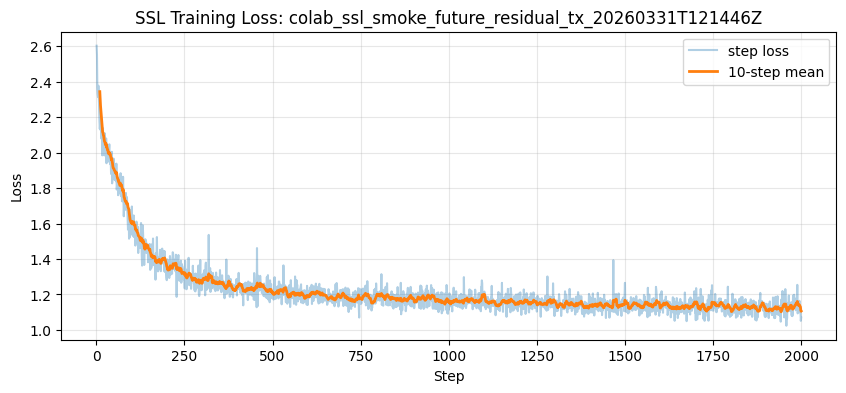

In [ ]:
# Plot loss curves for the current run.
import json

import matplotlib.pyplot as plt
import numpy as np

if "run_dir" not in globals():
    raise RuntimeError("Run the training cell first so `run_dir` is defined.")

progress_path = run_dir / "progress.jsonl"
text = progress_path.read_text()

records = []
try:
    for line in text.splitlines():
        line = line.strip()
        if line:
            records.append(json.loads(line))
except json.JSONDecodeError:
    repaired = text.replace("\\n{", "\n{").replace("\\n", "\n")
    records = [json.loads(line) for line in repaired.splitlines() if line.strip()]

if not records:
    raise RuntimeError(f"No progress records found in {progress_path}")

steps = np.array([r["step"] for r in records], dtype=np.int64)
losses = np.array([r["loss"] for r in records], dtype=np.float32)
elapsed = np.array([
    r.get("elapsed_seconds", r.get("elapsed_sec", 0.0))
    for r in records
], dtype=np.float32)

window = 10
if len(losses) >= window:
    smooth = np.convolve(losses, np.ones(window) / window, mode="valid")
    smooth_steps = steps[window - 1 :]
else:
    smooth = losses
    smooth_steps = steps

print("run_dir:", run_dir)
print("num_records:", len(records))
print("start_loss:", float(losses[0]))
print("final_loss:", float(losses[-1]))
print("best_loss:", float(losses.min()), "at step", int(steps[losses.argmin()]))
print("total_minutes:", float(elapsed[-1] / 60.0))

plt.figure(figsize=(10, 4))
plt.plot(steps, losses, alpha=0.35, label="step loss")
plt.plot(smooth_steps, smooth, linewidth=2, label=f"{window}-step mean")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title(f"SSL Training Loss: {run_dir.name}")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [ ]:
# Compare the trained model to simple baselines.
import random
from collections import defaultdict

import numpy as np
import torch

if "model" not in globals():
    raise RuntimeError("Run the training cell first so `model` is defined.")

EVAL_SEED = 123
EVAL_BATCHES = 20
EVAL_BATCH_SIZE = globals().get("BATCH_SIZE", 64)

RNG = random.Random(EVAL_SEED)
np_rng = np.random.default_rng(EVAL_SEED)

def future_prediction_loss_breakdown(predictions, x, valid_lens, feature_mask, context_lens, channel_weights=None, horizons=HORIZONS):
    overall_sse = x.new_tensor(0.0)
    overall_weight = x.new_tensor(0.0)
    by_horizon = {}

    for horizon in horizons:
        pred = predictions[horizon]
        horizon_sse = x.new_tensor(0.0)
        horizon_weight = x.new_tensor(0.0)

        for i in range(x.shape[0]):
            valid_len = int(valid_lens[i].item())
            context_len = int(context_lens[i].item())
            start_t = max(0, context_len - horizon)
            end_t = valid_len - horizon
            if end_t <= start_t:
                continue

            feat_mask = get_objective_feature_mask(feature_mask[i])
            if not feat_mask.any():
                continue

            current = x[i, start_t:end_t][:, feat_mask]
            target_future = x[i, start_t + horizon : end_t + horizon][:, feat_mask]
            pred_slice = pred[i, start_t:end_t][:, feat_mask]
            future_guess = reconstruct_future_from_output(pred_slice, current)
            diff_sq = (future_guess - target_future).pow(2)

            if channel_weights is None:
                horizon_sse = horizon_sse + diff_sq.sum()
                horizon_weight = horizon_weight + diff_sq.numel()
            else:
                feat_weights = channel_weights[i, feat_mask].unsqueeze(0)
                horizon_sse = horizon_sse + (diff_sq * feat_weights).sum()
                horizon_weight = horizon_weight + feat_weights.sum() * diff_sq.shape[0]

        by_horizon[horizon] = float((horizon_sse / horizon_weight).item()) if float(horizon_weight.item()) > 0 else float("nan")
        overall_sse = overall_sse + horizon_sse
        overall_weight = overall_weight + horizon_weight

    overall = float((overall_sse / overall_weight).item())
    return overall, by_horizon

results = {
    "trained": [],
    "persistence": [],
    "raw_zero": [],
}
per_horizon = {
    "trained": defaultdict(list),
    "persistence": defaultdict(list),
    "raw_zero": defaultdict(list),
}

was_training = model.training
model.eval()

with torch.no_grad():
    for _ in range(EVAL_BATCHES):
        batch = sample_batch_balanced(batch_size=EVAL_BATCH_SIZE, window_size=WINDOW_SIZE)
        x = batch["x"].to(DEVICE)
        valid_lens = batch["valid_lens"].to(DEVICE)
        feature_mask = batch["feature_mask"].to(DEVICE)
        context_lens = batch["context_lens"].to(DEVICE)

        channel_weights = get_batch_channel_weights(batch, DEVICE)
        trained_predictions = model(x, valid_lens)
        persistence_predictions = {h: torch.zeros_like(x) for h in HORIZONS}
        if PREDICTION_TARGET == "residual":
            raw_zero_predictions = {h: -x.clone() for h in HORIZONS}
        else:
            raw_zero_predictions = {h: torch.zeros_like(x) for h in HORIZONS}

        for name, preds in [
            ("trained", trained_predictions),
            ("persistence", persistence_predictions),
            ("raw_zero", raw_zero_predictions),
        ]:
            overall, by_h = future_prediction_loss_breakdown(
                preds,
                x,
                valid_lens,
                feature_mask,
                context_lens,
                channel_weights=channel_weights,
            )
            results[name].append(overall)
            for horizon, value in by_h.items():
                per_horizon[name][horizon].append(value)

if was_training:
    model.train()

print("overall mean loss across eval batches:")
for name, values in results.items():
    arr = np.array(values, dtype=np.float64)
    print(f" - {name:11s}: {arr.mean():.4f} +/- {arr.std(ddof=0):.4f}")

print("\nper-horizon mean loss:")
for horizon in HORIZONS:
    print(f"h={horizon}")
    for name, horizon_dict in per_horizon.items():
        arr = np.array(horizon_dict[horizon], dtype=np.float64)
        print(f" - {name:11s}: {arr.mean():.4f}")

print("\ncomparisons:")
print(f" - trained - persistence = {np.mean(results['trained']) - np.mean(results['persistence']):+.4f}")
print(f" - trained - raw_zero    = {np.mean(results['trained']) - np.mean(results['raw_zero']):+.4f}")


overall mean loss across eval batches:
 - trained    : 1.0977 +/- 0.0320
 - persistence: 2.0496 +/- 0.0534
 - raw_zero   : 1.1173 +/- 0.0334

per-horizon mean loss:
h=1
 - trained    : 1.0977
 - persistence: 2.0496
 - raw_zero   : 1.1173

comparisons:
 - trained - persistence = -0.9519
 - trained - raw_zero    = -0.0196


In [ ]:
# Diagnose channel predictability and build loss weights.
import copy
import math
from collections import defaultdict

if "sample_batch_balanced" not in globals():
    raise RuntimeError("Run the training cell first so sample_batch_balanced is defined.")
if "model" not in globals():
    raise RuntimeError("Run the training cell first so model is defined.")

DIAG_BATCHES = 32
DIAG_BATCH_SIZE = globals().get("EVAL_BATCH_SIZE", globals().get("BATCH_SIZE", 32))
PREDICTABILITY_WEIGHT_FLOOR = 0.25
PREDICTABILITY_TOP_FRACTION = 0.25
ACTIVITY_TOP_FRACTION = 0.25
MIN_CHANNEL_SAMPLES = 128

def _empty_session_stats():
    return {
        "zero_sse": torch.zeros(FULL_DIM, dtype=torch.float64),
        "model_sse": torch.zeros(FULL_DIM, dtype=torch.float64),
        "persistence_sse": torch.zeros(FULL_DIM, dtype=torch.float64),
        "count": torch.zeros(FULL_DIM, dtype=torch.float64),
        "raw_sum": torch.zeros(FULL_DIM, dtype=torch.float64),
        "raw_sumsq": torch.zeros(FULL_DIM, dtype=torch.float64),
        "raw_count": torch.zeros(FULL_DIM, dtype=torch.float64),
    }

session_stats = defaultdict(_empty_session_stats)
saved_np_state = copy.deepcopy(np_rng.bit_generator.state)
saved_rng_state = RNG.getstate()
was_training = model.training
model.eval()

with torch.no_grad():
    for _ in range(DIAG_BATCHES):
        batch = sample_batch_balanced(batch_size=DIAG_BATCH_SIZE, window_size=WINDOW_SIZE)
        x = batch["x"].to(DEVICE)
        valid_lens = batch["valid_lens"].to(DEVICE)
        feature_mask = batch["feature_mask"].to(DEVICE)
        context_lens = batch["context_lens"].to(DEVICE)
        trained_preds = model(x, valid_lens)

        for i, session_key in enumerate(batch["session_keys"]):
            stats = session_stats[session_key]
            feat_mask = get_objective_feature_mask(feature_mask[i])
            present_idx = torch.nonzero(feat_mask, as_tuple=False).squeeze(1).cpu()
            if present_idx.numel() == 0:
                continue

            raw_valid = x[i, :valid_len][:, feat_mask]
            stats["raw_sum"][present_idx] += raw_valid.sum(dim=0).cpu().to(torch.float64)
            stats["raw_sumsq"][present_idx] += raw_valid.pow(2).sum(dim=0).cpu().to(torch.float64)
            stats["raw_count"][present_idx] += raw_valid.shape[0]

            for horizon in HORIZONS:
                valid_len = int(valid_lens[i].item())
                context_len = int(context_lens[i].item())
                start_t = max(0, context_len - horizon)
                end_t = valid_len - horizon
                if end_t <= start_t:
                    continue

                current = x[i, start_t:end_t][:, feat_mask]
                future = x[i, start_t + horizon : end_t + horizon][:, feat_mask]
                model_guess = reconstruct_future_from_output(trained_preds[horizon][i, start_t:end_t][:, feat_mask], current)
                persistence_guess = current
                zero_guess = torch.zeros_like(current)

                stats["model_sse"][present_idx] += (model_guess - future).pow(2).sum(dim=0).cpu().to(torch.float64)
                stats["persistence_sse"][present_idx] += (persistence_guess - future).pow(2).sum(dim=0).cpu().to(torch.float64)
                stats["zero_sse"][present_idx] += (zero_guess - future).pow(2).sum(dim=0).cpu().to(torch.float64)
                stats["count"][present_idx] += future.shape[0]

if was_training:
    model.train()

np_rng.bit_generator.state = saved_np_state
RNG.setstate(saved_rng_state)

predictability_weights_by_session = {}
activity_top_quartile_weights_by_session = {}
session_diagnostics = {}

for session_key in sorted(session_stats):
    stats = session_stats[session_key]
    count = stats["count"].numpy()
    valid = count >= MIN_CHANNEL_SAMPLES
    zero_mse = np.full(FULL_DIM, np.nan, dtype=np.float64)
    persistence_mse = np.full(FULL_DIM, np.nan, dtype=np.float64)
    model_mse = np.full(FULL_DIM, np.nan, dtype=np.float64)
    raw_mean = np.full(FULL_DIM, np.nan, dtype=np.float64)

    zero_mse[valid] = stats["zero_sse"].numpy()[valid] / count[valid]
    persistence_mse[valid] = stats["persistence_sse"].numpy()[valid] / count[valid]
    model_mse[valid] = stats["model_sse"].numpy()[valid] / count[valid]
    raw_valid = stats["raw_count"].numpy() >= MIN_CHANNEL_SAMPLES
    raw_mean[raw_valid] = stats["raw_sum"].numpy()[raw_valid] / stats["raw_count"].numpy()[raw_valid]

    predictability = zero_mse - persistence_mse
    model_gain = persistence_mse - model_mse

    objective_valid = np.flatnonzero(valid)
    positive_predictable = objective_valid[predictability[objective_valid] > 0]
    positive_predictable = positive_predictable[np.argsort(-predictability[positive_predictable])]

    n_select = 0
    if positive_predictable.size > 0:
        n_select = max(1, math.ceil(positive_predictable.size * PREDICTABILITY_TOP_FRACTION))
    selected = positive_predictable[:n_select]

    weights = np.full(FULL_DIM, PREDICTABILITY_WEIGHT_FLOOR, dtype=np.float32)
    weights[~valid] = 0.0
    if selected.size > 0:
        weights[selected] = 1.0

    activity_candidates = objective_valid[raw_valid[objective_valid]]
    activity_selected = np.array([], dtype=np.int64)
    if activity_candidates.size > 0:
        ranked = activity_candidates[np.argsort(-raw_mean[activity_candidates])]
        n_activity = max(1, math.ceil(ranked.size * ACTIVITY_TOP_FRACTION))
        activity_selected = ranked[:n_activity]
    activity_weights = np.zeros(FULL_DIM, dtype=np.float32)
    activity_weights[activity_selected] = 1.0
    tx_valid = int(np.sum(valid[:TX_DIM]))
    sbp_valid = int(np.sum(valid[TX_DIM:]))
    tx_selected = int(np.sum(selected < TX_DIM))
    sbp_selected = int(np.sum(selected >= TX_DIM))

    predictability_weights_by_session[session_key] = weights
    activity_top_quartile_weights_by_session[session_key] = activity_weights
    session_diagnostics[session_key] = {
        "valid_channels": int(valid.sum()),
        "tx_valid_channels": tx_valid,
        "sbp_valid_channels": sbp_valid,
        "positive_predictable": int(positive_predictable.size),
        "selected": int(selected.size),
        "activity_selected": int(activity_selected.size),
        "tx_selected": tx_selected,
        "sbp_selected": sbp_selected,
        "activity_top_channels": [int(ch) for ch in activity_selected[:5]],
        "top_channels": [
            {
                "channel": int(ch),
                "predictability": float(predictability[ch]),
                "model_gain": float(model_gain[ch]),
                "zero_mse": float(zero_mse[ch]),
                "persistence_mse": float(persistence_mse[ch]),
                "model_mse": float(model_mse[ch]),
            }
            for ch in positive_predictable[:5]
        ],
    }

print("objective:", OBJECTIVE_NAME)
print("prediction target:", PREDICTION_TARGET)
print("tx only target:", USE_TX_ONLY_TARGET)
print("sessions analyzed:", len(session_diagnostics))
for session_key, info in list(session_diagnostics.items())[:10]:
    print(session_key)
    print(
        f"  valid_channels={info['valid_channels']} positive_predictable={info['positive_predictable']} "
        f"selected={info['selected']} activity_selected={info['activity_selected']} "
        f"tx_selected={info['tx_selected']} sbp_selected={info['sbp_selected']}"
    )
    if info["activity_top_channels"]:
        print(f"  activity_top_channels={info['activity_top_channels']}")
    for item in info["top_channels"]:
        print(
            f"  ch={item['channel']:03d} pred={item['predictability']:+.4f} gain={item['model_gain']:+.4f} "
            f"zero={item['zero_mse']:.4f} pers={item['persistence_mse']:.4f} model={item['model_mse']:.4f}"
        )
    if not info["top_channels"]:
        print("  no positive-predictable channels met the minimum count")
    print()

USE_ACTIVITY_TOP_QUARTILE = True
USE_PREDICTABILITY_WEIGHTING = False
print("USE_ACTIVITY_TOP_QUARTILE set to True")
print("USE_PREDICTABILITY_WEIGHTING set to False")


objective: future_residual_tx
prediction target: residual
tx only target: True
sessions analyzed: 195
000950:sub-T5-held-in-calib_ses-20220518
  valid_channels=192 positive_predictable=0 selected=0 tx_selected=0 sbp_selected=0
  no positive-predictable channels met the minimum count

000950:sub-T5-held-in-calib_ses-20220523
  valid_channels=192 positive_predictable=1 selected=1 tx_selected=1 sbp_selected=0
  ch=022 pred=+0.3226 gain=+0.2213 zero=1.2840 pers=0.9614 model=0.7401

000950:sub-T5-held-in-calib_ses-20220525
  valid_channels=192 positive_predictable=2 selected=1 tx_selected=1 sbp_selected=0
  ch=188 pred=+1.4575 gain=+0.6223 zero=4.1941 pers=2.7366 model=2.1143
  ch=022 pred=+0.2992 gain=+0.2491 zero=1.2769 pers=0.9778 model=0.7286

000950:sub-T5-held-in-calib_ses-20220601
  valid_channels=192 positive_predictable=3 selected=1 tx_selected=1 sbp_selected=0
  ch=180 pred=+0.0219 gain=+0.4923 zero=1.5612 pers=1.5393 model=1.0470
  ch=124 pred=+0.0070 gain=-0.0043 zero=0.0160 per

In [ ]:
# Summarize predictability/model-gain across sessions.
import numpy as np

if "session_diagnostics" not in globals():
    raise RuntimeError("Run the channel diagnostics cell first so `session_diagnostics` is defined.")

sessions = list(session_diagnostics.items())
n_sessions = len(sessions)

positive_counts = np.array([info["positive_predictable"] for _, info in sessions], dtype=np.int64)
selected_counts = np.array([info["selected"] for _, info in sessions], dtype=np.int64)

all_top = []
all_selected_positive_gain = 0
all_selected_total = 0
sessions_with_model_beats_zero = 0
sessions_with_model_beats_persistence = 0

for session_key, info in sessions:
    top = info.get("top_channels", [])
    all_top.extend((session_key, item) for item in top)

    if any(item["model_mse"] < item["zero_mse"] for item in top):
        sessions_with_model_beats_zero += 1
    if any(item["model_mse"] < item["persistence_mse"] for item in top):
        sessions_with_model_beats_persistence += 1

    selected = top[: info["selected"]]
    all_selected_total += len(selected)
    all_selected_positive_gain += sum(item["model_gain"] > 0 for item in selected)

all_model_beats_zero = sum(item["model_mse"] < item["zero_mse"] for _, item in all_top)
all_model_beats_persistence = sum(item["model_gain"] > 0 for _, item in all_top)

print("global summary")
print("sessions:", n_sessions)
print("median positive_predictable per session:", float(np.median(positive_counts)))
print("mean positive_predictable per session:", float(positive_counts.mean()))
print("max positive_predictable in a session:", int(positive_counts.max()))
print("sessions with >=1 positive_predictable:", int((positive_counts > 0).sum()))
print("sessions with >=1 selected channel:", int((selected_counts > 0).sum()))
print("sessions where a top channel beats zero:", sessions_with_model_beats_zero)
print("sessions where a top channel beats persistence:", sessions_with_model_beats_persistence)

if all_selected_total > 0:
    print("selected channels with positive gain:", f"{all_selected_positive_gain}/{all_selected_total}",
          f"({all_selected_positive_gain / all_selected_total:.1%})")

if all_top:
    print("top-listed channels beating zero:", f"{all_model_beats_zero}/{len(all_top)}",
          f"({all_model_beats_zero / len(all_top):.1%})")
    print("top-listed channels beating persistence:", f"{all_model_beats_persistence}/{len(all_top)}",
          f"({all_model_beats_persistence / len(all_top):.1%})")

best_by_model_vs_zero = sorted(
    all_top,
    key=lambda x: x[1]["zero_mse"] - x[1]["model_mse"],
    reverse=True,
)[:10]

best_by_gain_vs_persistence = sorted(
    all_top,
    key=lambda x: x[1]["model_gain"],
    reverse=True,
)[:10]

print("\nbest channels by model improvement over zero:")
for session_key, item in best_by_model_vs_zero:
    delta = item["zero_mse"] - item["model_mse"]
    print(
        f"{session_key} ch={item['channel']:03d} "
        f"zero={item['zero_mse']:.4f} pers={item['persistence_mse']:.4f} "
        f"model={item['model_mse']:.4f} "
        f"model_minus_zero={-delta:+.4f} gain={item['model_gain']:+.4f}"
    )

print("\nbest channels by model improvement over persistence:")
for session_key, item in best_by_gain_vs_persistence:
    print(
        f"{session_key} ch={item['channel']:03d} "
        f"pred={item['predictability']:+.4f} gain={item['model_gain']:+.4f} "
        f"zero={item['zero_mse']:.4f} pers={item['persistence_mse']:.4f} "
        f"model={item['model_mse']:.4f}"
    )


global summary
sessions: 195
median positive_predictable per session: 1.0
mean positive_predictable per session: 2.7384615384615385
max positive_predictable in a session: 25
sessions with >=1 positive_predictable: 110
sessions with >=1 selected channel: 110
sessions where a top channel beats zero: 91
sessions where a top channel beats persistence: 83
selected channels with positive gain: 89/182 (48.9%)
top-listed channels beating zero: 193/319 (60.5%)
top-listed channels beating persistence: 124/319 (38.9%)

best channels by model improvement over zero:
unsupervised_cursor_recalibration_offline:t5.2019.04.01 ch=082 zero=14.0209 pers=1.5501 model=4.0996 model_minus_zero=-9.9213 gain=-2.5496
unsupervised_cursor_recalibration_offline:t5.2019.05.29 ch=076 zero=17.8381 pers=3.2795 model=8.7548 model_minus_zero=-9.0834 gain=-5.4752
unsupervised_cursor_recalibration_offline:t5.2019.04.01 ch=189 zero=11.7600 pers=5.2259 model=3.8797 model_minus_zero=-7.8803 gain=+1.3461
motor_data:t12.2024.12.

win-margin summary
channels analyzed: 32064
mean(model - zero): -0.01724355618596953
median(model - zero): 0.005574710566592839
mean(model - persistence): -0.9502508397373814
median(model - persistence): -0.9776163245692396

fractions beating baselines by margin
eps=0.00  beat_zero=41.8%  beat_persistence=97.6%  beat_both=41.4%
eps=0.01  beat_zero=34.7%  beat_persistence=97.2%  beat_both=34.6%
eps=0.05  beat_zero=20.2%  beat_persistence=96.8%  beat_both=20.2%
eps=0.10  beat_zero=11.8%  beat_persistence=96.0%  beat_both=11.7%
eps=0.25  beat_zero=3.6%  beat_persistence=91.5%  beat_both=3.5%

quantiles of model - zero
q=0.01: -0.4974
q=0.05: -0.1987
q=0.10: -0.1165
q=0.25: -0.0335
q=0.50: +0.0056
q=0.75: +0.0228
q=0.90: +0.0516
q=0.95: +0.0922
q=0.99: +0.2848

quantiles of model - persistence
q=0.01: -2.3633
q=0.05: -1.6804
q=0.10: -1.4523
q=0.25: -1.1962
q=0.50: -0.9776
q=0.75: -0.6894
q=0.90: -0.2942
q=0.95: -0.1370
q=0.99: +0.0286

strong-win channel counts (eps=0.10)
strong zero wins:

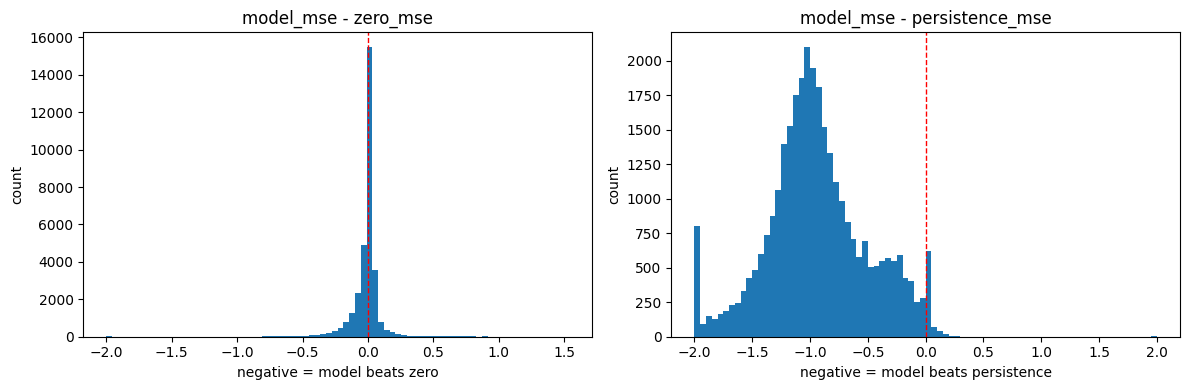

In [ ]:
# Summarize win margins over zero and persistence.
import numpy as np
import matplotlib.pyplot as plt

if "rows" not in globals():
    raise RuntimeError("Run the prediction-behavior cell first so `rows` is defined.")

delta_zero = np.array([r["model_mse"] - r["zero_mse"] for r in rows], dtype=np.float64)
delta_persistence = np.array([r["model_mse"] - r["persistence_mse"] for r in rows], dtype=np.float64)
alpha_vals = np.array([r["alpha"] for r in rows], dtype=np.float64)

epsilons = [0.0, 0.01, 0.05, 0.10, 0.25]

print("win-margin summary")
print("channels analyzed:", len(rows))
print("mean(model - zero):", float(delta_zero.mean()))
print("median(model - zero):", float(np.median(delta_zero)))
print("mean(model - persistence):", float(delta_persistence.mean()))
print("median(model - persistence):", float(np.median(delta_persistence)))

print("\nfractions beating baselines by margin")
for eps in epsilons:
    frac_zero = np.mean(delta_zero < -eps)
    frac_persist = np.mean(delta_persistence < -eps)
    frac_both = np.mean((delta_zero < -eps) & (delta_persistence < -eps))
    print(
        f"eps={eps:>4.2f}  "
        f"beat_zero={frac_zero:.1%}  "
        f"beat_persistence={frac_persist:.1%}  "
        f"beat_both={frac_both:.1%}"
    )

print("\nquantiles of model - zero")
for q in [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]:
    print(f"q={q:>4.2f}: {np.quantile(delta_zero, q):+.4f}")

print("\nquantiles of model - persistence")
for q in [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]:
    print(f"q={q:>4.2f}: {np.quantile(delta_persistence, q):+.4f}")

strong_zero_wins = [r for r in rows if (r["model_mse"] - r["zero_mse"]) < -0.10]
strong_persist_wins = [r for r in rows if (r["model_mse"] - r["persistence_mse"]) < -0.10]
strong_both_wins = [
    r for r in rows
    if (r["model_mse"] - r["zero_mse"] < -0.10 and r["model_mse"] - r["persistence_mse"] < -0.10)
]

print("\nstrong-win channel counts (eps=0.10)")
print("strong zero wins:", len(strong_zero_wins))
print("strong persistence wins:", len(strong_persist_wins))
print("strong both wins:", len(strong_both_wins))

if strong_both_wins:
    strong_alpha = np.array([r["alpha"] for r in strong_both_wins], dtype=np.float64)
    print("strong-both alpha median:", float(np.median(strong_alpha)))
    print("strong-both alpha mean:", float(strong_alpha.mean()))
    print("strong-both alpha < 0.25:", f"{np.mean(strong_alpha < 0.25):.1%}")
    print("strong-both alpha 0.75..1.25:", f"{np.mean((strong_alpha >= 0.75) & (strong_alpha <= 1.25)):.1%}")

best_vs_zero = sorted(rows, key=lambda r: r["model_mse"] - r["zero_mse"])[:10]
best_vs_persistence = sorted(rows, key=lambda r: r["model_mse"] - r["persistence_mse"])[:10]

print("\nbest channels vs zero")
for r in best_vs_zero:
    print(
        f"{r['session_key']} ch={r['channel']:03d} "
        f"model-zero={r['model_mse'] - r['zero_mse']:+.4f} "
        f"model-pers={r['model_mse'] - r['persistence_mse']:+.4f} "
        f"alpha={r['alpha']:.3f} "
        f"model={r['model_mse']:.4f} zero={r['zero_mse']:.4f} pers={r['persistence_mse']:.4f}"
    )

print("\nbest channels vs persistence")
for r in best_vs_persistence:
    print(
        f"{r['session_key']} ch={r['channel']:03d} "
        f"model-zero={r['model_mse'] - r['zero_mse']:+.4f} "
        f"model-pers={r['model_mse'] - r['persistence_mse']:+.4f} "
        f"alpha={r['alpha']:.3f} "
        f"model={r['model_mse']:.4f} zero={r['zero_mse']:.4f} pers={r['persistence_mse']:.4f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(np.clip(delta_zero, -2, 2), bins=80)
axes[0].axvline(0.0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("model_mse - zero_mse")
axes[0].set_xlabel("negative = model beats zero")
axes[0].set_ylabel("count")

axes[1].hist(np.clip(delta_persistence, -2, 2), bins=80)
axes[1].axvline(0.0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("model_mse - persistence_mse")
axes[1].set_xlabel("negative = model beats persistence")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()


In [15]:
# Check whether raw channel magnitude/variance relates to predictability.
import copy
from collections import defaultdict

import numpy as np
import torch

if "rows_by_dataset" not in globals():
    raise RuntimeError("Run the dataset-loading cells first.")
if "rows" not in globals():
    raise RuntimeError("Run the prediction-behavior cell first so `rows` is defined.")

RAW_STAT_BATCHES = 32
RAW_STAT_BATCH_SIZE = globals().get("EVAL_BATCH_SIZE", globals().get("BATCH_SIZE", 64))
MIN_CHANNEL_SAMPLES = 128

def _empty_raw_stats():
    return {
        "count": torch.zeros(FULL_DIM, dtype=torch.float64),
        "sum": torch.zeros(FULL_DIM, dtype=torch.float64),
        "sumsq": torch.zeros(FULL_DIM, dtype=torch.float64),
    }

raw_stats = defaultdict(_empty_raw_stats)
saved_np_state = copy.deepcopy(np_rng.bit_generator.state)
saved_rng_state = RNG.getstate()

with torch.no_grad():
    for _ in range(RAW_STAT_BATCHES):
        batch = []
        for _ in range(RAW_STAT_BATCH_SIZE):
            dataset_idx = int(np_rng.choice(len(pretrain_datasets), p=dataset_probs))
            dataset = pretrain_datasets[dataset_idx]
            row_idx = int(np_rng.choice(len(rows_by_dataset[dataset]), p=example_probs_by_dataset[dataset]))
            example = rows_by_dataset[dataset][row_idx]
            sample = load_random_window(example, window_size=WINDOW_SIZE)
            batch.append(sample)

        for sample in batch:
            session_key = sample["session_key"]
            stats = raw_stats[session_key]

            x = sample["x"]
            valid_len = int(sample["valid_len"])
            feat_mask = get_objective_feature_mask(sample["feature_mask"])
            present_idx = torch.nonzero(feat_mask.bool(), as_tuple=False).squeeze(1)
            if present_idx.numel() == 0 or valid_len <= 0:
                continue

            x_valid = x[:valid_len, feat_mask.bool()].to(torch.float64)
            stats["count"][present_idx] += valid_len
            stats["sum"][present_idx] += x_valid.sum(dim=0)
            stats["sumsq"][present_idx] += x_valid.pow(2).sum(dim=0)

np_rng.bit_generator.state = saved_np_state
RNG.setstate(saved_rng_state)

joined = []
for r in rows:
    session_key = r["session_key"]
    ch = r["channel"]
    stats = raw_stats.get(session_key)
    if stats is None:
        continue
    count = stats["count"][ch].item()
    if count < MIN_CHANNEL_SAMPLES:
        continue

    raw_mean = stats["sum"][ch].item() / count
    raw_var = max(stats["sumsq"][ch].item() / count - raw_mean ** 2, 0.0)
    raw_std = raw_var ** 0.5

    joined.append({
        **r,
        "raw_mean": raw_mean,
        "raw_std": raw_std,
        "delta_zero": r["model_mse"] - r["zero_mse"],
        "delta_persistence": r["model_mse"] - r["persistence_mse"],
    })

if not joined:
    raise RuntimeError("No joined raw-stat rows found.")

def rankdata(x):
    order = np.argsort(x)
    ranks = np.empty_like(order, dtype=np.float64)
    ranks[order] = np.arange(len(x), dtype=np.float64)
    return ranks

def spearman(x, y):
    xr = rankdata(np.asarray(x, dtype=np.float64))
    yr = rankdata(np.asarray(y, dtype=np.float64))
    xrc = xr - xr.mean()
    yrc = yr - yr.mean()
    denom = np.sqrt((xrc ** 2).sum() * (yrc ** 2).sum())
    return float((xrc * yrc).sum() / denom) if denom > 0 else float("nan")

raw_mean = np.array([r["raw_mean"] for r in joined], dtype=np.float64)
raw_std = np.array([r["raw_std"] for r in joined], dtype=np.float64)
delta_zero = np.array([r["delta_zero"] for r in joined], dtype=np.float64)
delta_persistence = np.array([r["delta_persistence"] for r in joined], dtype=np.float64)

print("raw-stat summary")
print("joined channels:", len(joined))
print("raw_mean median:", float(np.median(raw_mean)))
print("raw_std median:", float(np.median(raw_std)))

print("\nspearman correlations")
print("raw_mean vs model-zero        :", spearman(raw_mean, delta_zero))
print("raw_mean vs model-persistence :", spearman(raw_mean, delta_persistence))
print("raw_std  vs model-zero        :", spearman(raw_std, delta_zero))
print("raw_std  vs model-persistence :", spearman(raw_std, delta_persistence))

best_vs_zero = sorted(joined, key=lambda r: r["delta_zero"])[:10]
worst_vs_zero = sorted(joined, key=lambda r: r["delta_zero"], reverse=True)[:10]

print("\nbest channels vs zero")
for r in best_vs_zero:
    print(
        f"{r['session_key']} ch={r['channel']:03d} "
        f"delta_zero={r['delta_zero']:+.4f} delta_persist={r['delta_persistence']:+.4f} "
        f"raw_mean={r['raw_mean']:.4f} raw_std={r['raw_std']:.4f} alpha={r['alpha']:.3f}"
    )

print("\nworst channels vs zero")
for r in worst_vs_zero:
    print(
        f"{r['session_key']} ch={r['channel']:03d} "
        f"delta_zero={r['delta_zero']:+.4f} delta_persist={r['delta_persistence']:+.4f} "
        f"raw_mean={r['raw_mean']:.4f} raw_std={r['raw_std']:.4f} alpha={r['alpha']:.3f}"
    )


raw-stat summary
joined channels: 32064
raw_mean median: 0.1891594219924812
raw_std median: 0.4499409201186554

spearman correlations
raw_mean vs model-zero        : -0.3875461163558111
raw_mean vs model-persistence : -0.3305650306923258
raw_std  vs model-zero        : -0.37617183316600744
raw_std  vs model-persistence : -0.31923793808270595

best channels vs zero
unsupervised_cursor_recalibration_offline:t5.2019.04.01 ch=082 delta_zero=-9.9213 delta_persist=+2.5496 raw_mean=1.1112 raw_std=3.9392 alpha=0.549
unsupervised_cursor_recalibration_offline:t5.2019.05.29 ch=076 delta_zero=-9.0834 delta_persist=+5.4752 raw_mean=2.2679 raw_std=5.1261 alpha=0.368
unsupervised_cursor_recalibration_offline:t5.2019.04.01 ch=189 delta_zero=-7.8803 delta_persist=-1.3461 raw_mean=0.6663 raw_std=1.0500 alpha=0.629
motor_data:t12.2024.12.19 ch=120 delta_zero=-6.6582 delta_persist=-2.8958 raw_mean=0.3153 raw_std=0.7542 alpha=0.522
unsupervised_cursor_recalibration_offline:t5.2019.05.29 ch=189 delta_zero=-

In [17]:
# Win rates by raw-activity quantile.
import numpy as np

if "joined" not in globals():
    raise RuntimeError("Run the raw-stat analysis cell first so `joined` is defined.")

raw_mean = np.array([r["raw_mean"] for r in joined], dtype=np.float64)
raw_std = np.array([r["raw_std"] for r in joined], dtype=np.float64)
delta_zero = np.array([r["delta_zero"] for r in joined], dtype=np.float64)
delta_persistence = np.array([r["delta_persistence"] for r in joined], dtype=np.float64)

n_bins = 5
epsilons = [0.0, 0.01, 0.05, 0.10, 0.25]

def make_quantile_bins(x, n_bins=5):
    edges = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    for i in range(1, len(edges)):
        if edges[i] <= edges[i - 1]:
            edges[i] = edges[i - 1] + 1e-12
    bins = np.clip(np.digitize(x, edges[1:-1], right=False), 0, n_bins - 1)
    return bins, edges

mean_bin, mean_edges = make_quantile_bins(raw_mean, n_bins=n_bins)
std_bin, std_edges = make_quantile_bins(raw_std, n_bins=n_bins)

def print_win_table(name, bins, edges):
    print(f"\n{name} quantile win rates")
    for b in range(n_bins):
        mask = bins == b
        if not mask.any():
            continue

        print(
            f"{name}_q{b+1}: n={mask.sum():5d} "
            f"range=[{edges[b]:.4f}, {edges[b+1]:.4f}]"
        )

        for eps in epsilons:
            beat_zero = np.mean(delta_zero[mask] < -eps)
            beat_persist = np.mean(delta_persistence[mask] < -eps)
            beat_both = np.mean((delta_zero[mask] < -eps) & (delta_persistence[mask] < -eps))
            print(
                f"  eps={eps:>4.2f} "
                f"beat_zero={beat_zero:.1%} "
                f"beat_persistence={beat_persist:.1%} "
                f"beat_both={beat_both:.1%}"
            )

        print(
            f"  avg(model-zero)={delta_zero[mask].mean():+.4f} "
            f"median(model-zero)={np.median(delta_zero[mask]):+.4f}"
        )
        print(
            f"  avg(model-persist)={delta_persistence[mask].mean():+.4f} "
            f"median(model-persist)={np.median(delta_persistence[mask]):+.4f}"
        )

print_win_table("mean", mean_bin, mean_edges)
print_win_table("std", std_bin, std_edges)

# Compact summary for the strongest margin threshold.
eps = 0.10
print("\ncompact summary at eps=0.10")
for label, bins in [("mean", mean_bin), ("std", std_bin)]:
    vals = []
    for b in range(n_bins):
        mask = bins == b
        beat_both = np.mean((delta_zero[mask] < -eps) & (delta_persistence[mask] < -eps))
        vals.append(f"q{b+1}={beat_both:.1%}")
    print(f"{label}: " + "  ".join(vals))



mean quantile win rates
mean_q1: n= 6378 range=[0.0000, 0.0273]
  eps=0.00 beat_zero=6.6% beat_persistence=88.4% beat_both=5.0%
  eps=0.01 beat_zero=1.2% beat_persistence=86.2% beat_both=1.0%
  eps=0.05 beat_zero=0.0% beat_persistence=84.2% beat_both=0.0%
  eps=0.10 beat_zero=0.0% beat_persistence=80.6% beat_both=0.0%
  eps=0.25 beat_zero=0.0% beat_persistence=60.1% beat_both=0.0%
  avg(model-zero)=+0.0183 median(model-zero)=+0.0102
  avg(model-persist)=-0.3657 median(model-persist)=-0.3197
mean_q2: n= 6446 range=[0.0273, 0.1437]
  eps=0.00 beat_zero=24.1% beat_persistence=99.9% beat_both=24.1%
  eps=0.01 beat_zero=15.5% beat_persistence=99.9% beat_both=15.5%
  eps=0.05 beat_zero=4.8% beat_persistence=99.8% beat_both=4.8%
  eps=0.10 beat_zero=1.9% beat_persistence=99.5% beat_both=1.9%
  eps=0.25 beat_zero=0.4% beat_persistence=98.6% beat_both=0.4%
  avg(model-zero)=+0.0308 median(model-zero)=+0.0162
  avg(model-persist)=-1.1736 median(model-persist)=-1.1230
mean_q3: n= 6409 range=[0.1